# Rule-Guided Re-Constraint of Approximate Inverse Explanations

> Paper: T. Nakanishi, *NS-AIME: Rule-Guided Re-Constraint of Approximate Inverse Explanations*, 4th World Conference on Explainable AI (Late-breaking), 2026.

- This notebook runs the entire NS-AIME pipeline using the `ns_aime_xai2026` library:
1. **AIME Inverse Operator** `A† = Xᵀ Ŷ (ŶᵀŶ + εI)⁻¹`  (Equation 1)
2. **Rule Induction** (Monotonicity, Threshold, Pairwise AND, §3.2)
3. **Reconstraint Optimization** `min_B ‖B−A†‖² + α R_mono + β R_rule`  (Equation 2)
4. **Dual Reporting** (RD / GA / RS and audit flags, §3.4) + Catchy directed graph visualization (static and dynamic)




In [1]:
!pip install /content/ns_aime_xai2026-0.2.0.tar.gz

Processing ./ns_aime_xai2026-0.2.0.tar.gz
  Preparing metadata (setup.py) ... done
  Created wheel for ns-aime-xai2026: filename=ns_aime_xai2026-0.2.0-py3-none-any.whl size=23301 sha256=ea78bb10d7fac07b565a2d7a663068690ca838c8e95abdf951aec7b487dccfd9
  Stored in directory: /root/.cache/pip/wheels/d4/57/53/167754ce7952d4d5414fdc07d8d23a0c10f10b5cda57f1a044
Successfully built ns-aime-xai2026


In [10]:
import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import ns_aime_xai2026
from ns_aime_xai2026 import NSAIME, compute_metrics, plot_logic_graph, plot_dual_report, render_logic_graph_html
print("ns_aime_xai2026", ns_aime_xai2026.__version__)

RESULTS = os.path.abspath("./results/ns_aime_demo")
os.makedirs(RESULTS, exist_ok=True)


ns_aime_xai2026 0.2.0


## 1. Titanic (Tabular Format)

An example corresponding to Fig. 1 and Fig. 2 in the paper. Visualizes the rule structure for survivors (`survived`) and non-survivors (`not_survived`).

In [3]:
# Data Acquisition and Preprocessing
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url); df.columns = [c.lower() for c in df.columns]
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna("S")
df = df.dropna(subset=["fare"]).reset_index(drop=True)

feats = ["pclass","sex","age","sibsp","parch","fare","embarked"]
data = df[["survived"]+feats].copy()
oh = pd.get_dummies(data[["pclass","sex","embarked"]].astype(str)).astype(float)
data = pd.concat([data.drop(columns=["pclass","sex","embarked"]), oh], axis=1)

feature_names = [c for c in data.columns if c != "survived"]
X = data[feature_names].values.astype(float)
y = data["survived"].values.astype(int)
class_names = ["not_survived", "survived"]
print("X", X.shape, "| features:", feature_names)


X (891, 12) | features: ['age', 'sibsp', 'parch', 'fare', 'pclass_1', 'pclass_2', 'pclass_3', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S']


In [4]:
# Train the black-box model (fall back to RandomForest if LightGBM is not available)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

models = {"LogisticReg": LogisticRegression(max_iter=1000),
          "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42)}
try:
    import lightgbm as lgb
    models["LightGBM"] = lgb.LGBMClassifier(verbose=-1)
except Exception as e:
    print("LightGBM unavailable -> skipping:", e)

for name, mdl in models.items():
    mdl.fit(X_tr, y_tr)
    print(f"{name:14s} acc={accuracy_score(y_te, mdl.predict(X_te)):.3f}")


LogisticReg    acc=0.799
RandomForest   acc=0.817
LightGBM       acc=0.784


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [5]:
# NS-AIME: Comparison of raw AIME vs. NS-AIME across models (in the style of Table 1 in the paper)
rows = []
explainers = {}
for name, mdl in models.items():
    Yhat = mdl.predict_proba(X_tr)
    ex = NSAIME(alpha=1.0, beta=3.0, gamma=0.05, top_k=6, normalize=True)
    ex.fit(X_tr, Yhat, feature_names=feature_names, class_names=class_names)
    B = ex.optimize()
    raw = compute_metrics(ex.A_dagger_, ex.A_dagger_, ex._Xp_cache, ex.rules_)
    ns  = compute_metrics(B, ex.A_dagger_, ex._Xp_cache, ex.rules_)
    explainers[name] = (ex, B, raw, ns)
    rows.append([name, raw["rs"], ns["rs"], ns["rd"], ns["ga"]])

tbl = pd.DataFrame(rows, columns=["Model","RS(raw)","RS(NS-AIME)","RD↓","GA↑"]).round(3)
tbl


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,RS(raw),RS(NS-AIME),RD↓,GA↑
0,LogisticReg,0.703,0.707,0.184,0.995
1,RandomForest,0.717,0.723,0.320,0.987
2,LightGBM,0.716,0.722,0.303,0.988


model = LightGBM | RS 0.716 -> 0.722 | RD=0.30 GA=+0.99


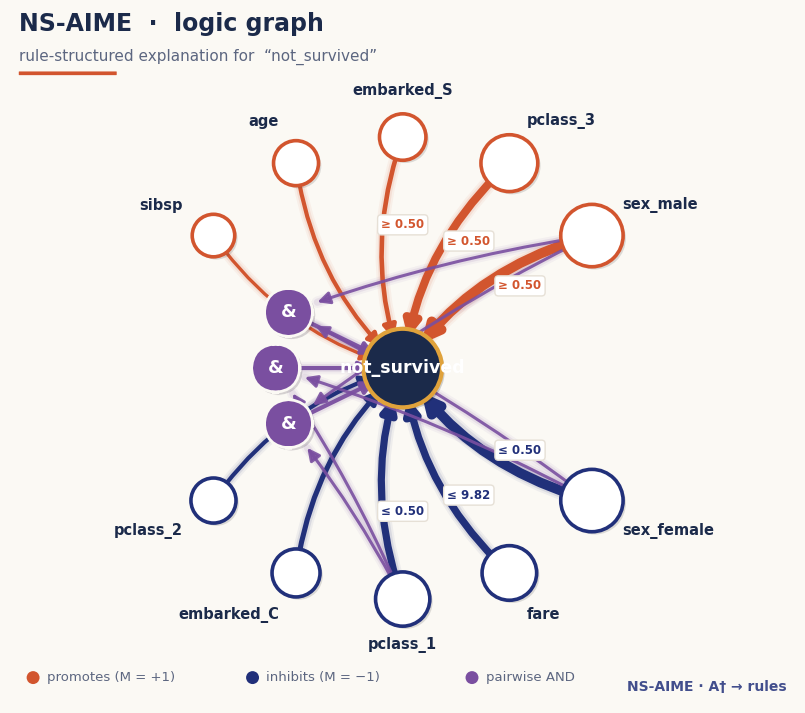

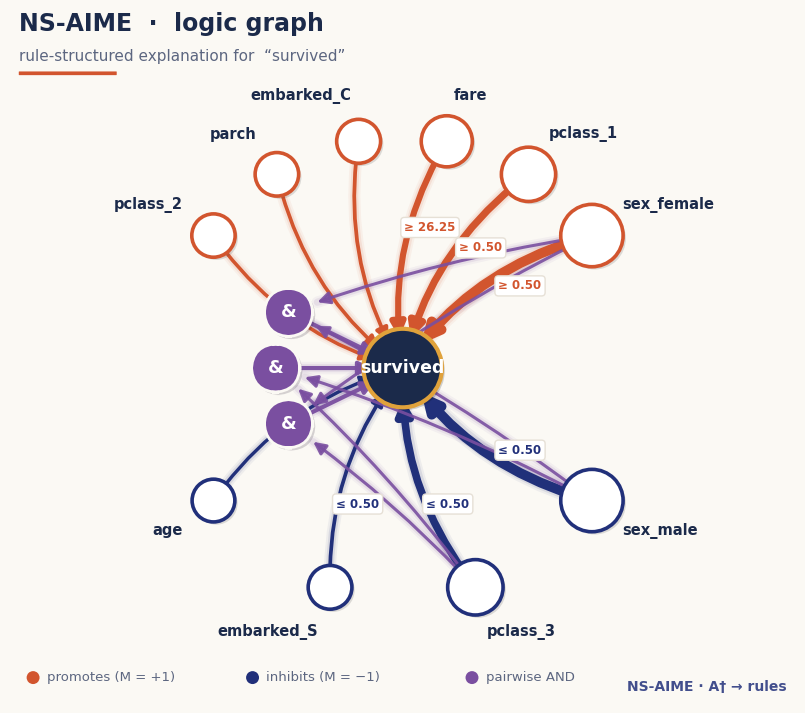

In [6]:
# Catchy Directed Graphs (Static, AIME-Style): LightGBM Preferred
name = "LightGBM" if "LightGBM" in explainers else list(explainers)[0]
ex, B, raw, ns = explainers[name]
print(f"model = {name} | RS {raw['rs']:.3f} -> {ns['rs']:.3f} | RD={ns['rd']:.2f} GA={ns['ga']:+.2f}")

for k, cname in enumerate(class_names):
    plot_logic_graph(B, ex.rules_, feature_names, class_index=k, class_name=cname,
                     top_k=10, save_path=os.path.join(RESULTS, f"titanic_logic_{cname}.png"))


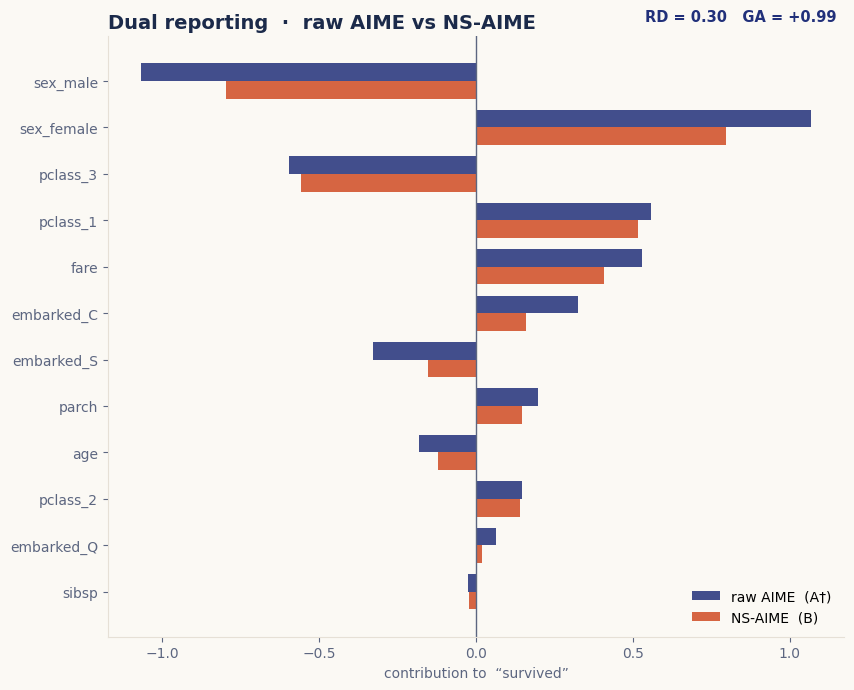

<Axes: title={'left': 'Dual reporting  ·  raw AIME vs NS-AIME'}, xlabel='contribution to  “survived”'>

In [7]:
# Dual reporting (Raw AIME vs. NS-AIME) — Significant discrepancies trigger an audit flag
plot_dual_report(ex.A_dagger_, B, feature_names, class_index=1, class_name="survived",
                 rd=ns["rd"], ga=ns["ga"], top_k=12,
                 save_path=os.path.join(RESULTS, "titanic_dual_report.png"))


In [9]:
# Interactive Visualization
import os
from IPython.display import HTML, display

path = os.path.join(RESULTS, "titanic_interactive.html")

render_logic_graph_html(
    B,
    ex.A_dagger_,
    ex.rules_,
    feature_names,
    class_names,
    metrics=ns,
    raw_metrics=raw,
    top_k=10,
    path=path,
    title=f"NS-AIME · Titanic · {name}"
)

print("wrote", path)

# Google Colab compatible display
with open(path, "r", encoding="utf-8") as f:
    html = f.read()

display(HTML(html))


wrote /content/results/ns_aime_demo/titanic_interactive.html


## 2. 20 Newsgroups (Sparse Text)
The setting where the paper **shows the greatest effectiveness**. With sparse TF–IDF, the presence rules are natural, and the RS improves significantly (Paper Table 1: 0.02–0.15 → 0.75–0.93). Rule graphs containing AND nodes can be drawn intuitively.

In [11]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

cats = ["sci.space", "rec.sport.baseball", "talk.politics.guns"]
ng = fetch_20newsgroups(subset="train", categories=cats,
                        remove=("headers","footers","quotes"))
vec = TfidfVectorizer(max_features=600, stop_words="english", min_df=5)
Xt = vec.fit_transform(ng.data)
words = vec.get_feature_names_out().tolist()
yt = ng.target
cls = [c.split(".")[-1] for c in ng.target_names]
print("TF-IDF:", Xt.shape, "| classes:", cls)


TF-IDF: (1736, 600) | classes: ['baseball', 'space', 'guns']


In [12]:
Xtr, Xte, ytr, yte = train_test_split(Xt, yt, test_size=0.3, random_state=42, stratify=yt)
clf = LogisticRegression(max_iter=2000, C=3.0).fit(Xtr, ytr)
from sklearn.metrics import accuracy_score
print("acc =", round(accuracy_score(yte, clf.predict(Xte)), 3))

Yhat = clf.predict_proba(Xtr)
# Do not standardize sparse text (use the “presence” rule). “beta” is a strong option.
exg = NSAIME(alpha=1.0, beta=12.0, gamma=0.02, top_k=8, normalize=False)
exg.fit(Xtr, Yhat, feature_names=words, class_names=cls)
Bg = exg.optimize(Xtr)
rawg = compute_metrics(exg.A_dagger_, exg.A_dagger_, Xtr, exg.rules_)
nsg  = compute_metrics(Bg, exg.A_dagger_, Xtr, exg.rules_)
print(f"RS {rawg['rs']:.3f} -> {nsg['rs']:.3f} | RD={nsg['rd']:.2f} GA={nsg['ga']:+.2f}")
n_presence = sum(1 for k in range(len(cls)) for r in exg.rules_[k] if r.get('presence'))
print("presence rules:", n_presence)


acc = 0.812
RS 0.999 -> 1.000 | RD=0.08 GA=+1.00
presence rules: 49


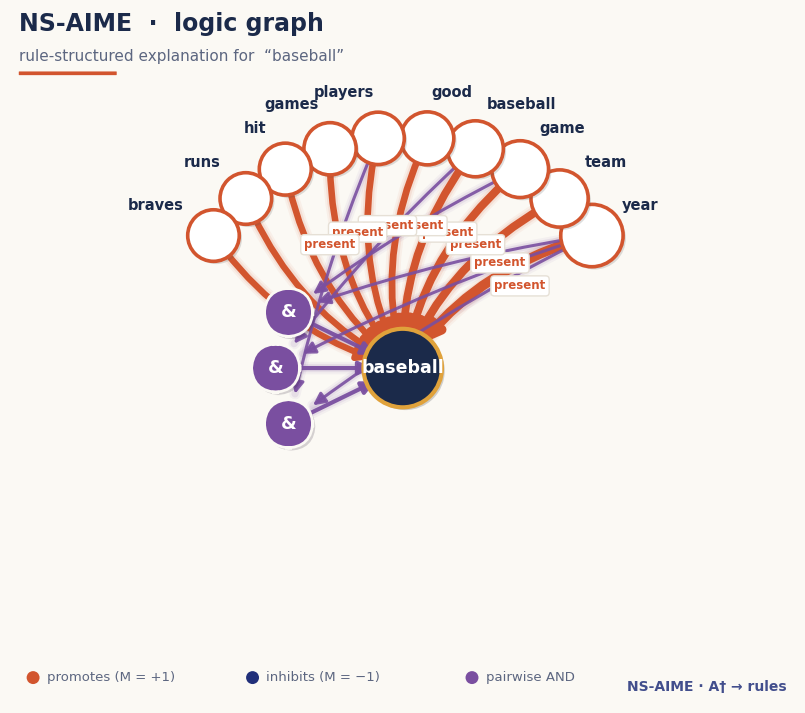

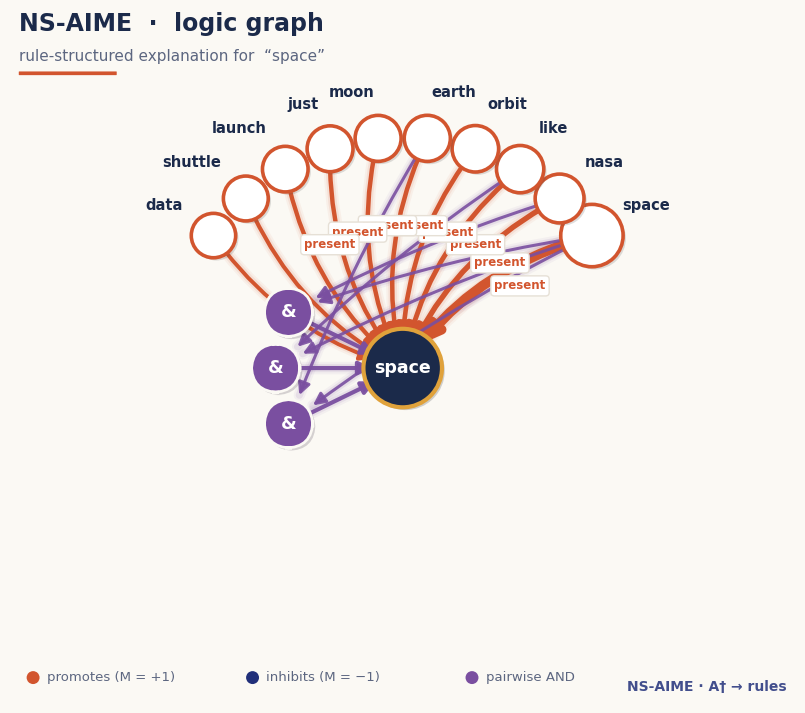

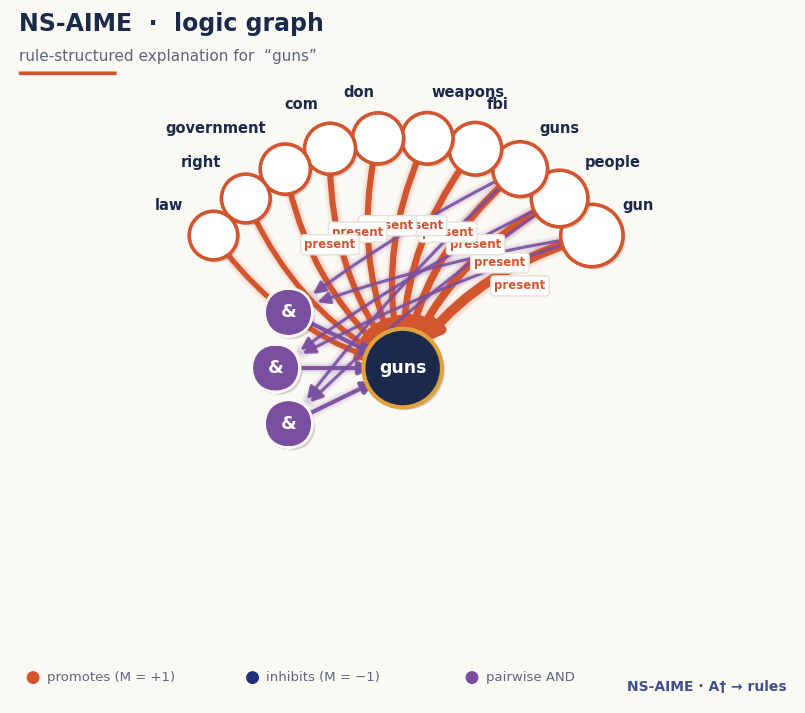

In [13]:
# Rule graph for text classes (where “presence + AND” really shines)
for k, cname in enumerate(cls):
    plot_logic_graph(Bg, exg.rules_, words, class_index=k, class_name=cname,
                     top_k=10, save_path=os.path.join(RESULTS, f"ng_logic_{cname}.png"))


In [14]:
path = os.path.join(RESULTS, "newsgroups_interactive.html")

render_logic_graph_html(
    Bg,
    exg.A_dagger_,
    exg.rules_,
    words,
    cls,
    metrics=nsg,
    raw_metrics=rawg,
    top_k=10,
    path=path,
    title="NS-AIME · 20 Newsgroups"
)

print("wrote", path)

from IPython.display import HTML, display

with open(path, "r", encoding="utf-8") as f:
    html = f.read()

display(HTML(html))


wrote /content/results/ns_aime_demo/newsgroups_interactive.html


## 3. Summary — Dual Reporting and Auditing

- When **RS increases** but **RD is high / GA is low**, the post-constraint explanation `B` deviates significantly from the inverse surrogate `A†` = **audit flag**.
- In that case, interpret `B` as **supplementary information** rather than a **replacement** for `A†` (see §3.4, to avoid fairwashing).
- The output is saved in `results/ns_aime_demo/` (static PNG and interactive HTML).
